# NB2 — Sentiment Analysis & Lead Indicator

**Scope.** Produces `outputs/nb2_seller_sentiment_scores.parquet` and analyses whether a drop in per-seller sentiment *precedes* a drop in per-seller weekly order volume (joining `outputs/nb1_weekly_order_volume.parquet` from NB1).

**Rubric surface hit.** SparkSQL join via temp view · MLlib `Pipeline(Tokenizer → StopWordsRemover[pt] → HashingTF → IDF → LogisticRegression)` evaluated with AUC · Deep-learning model (PyTorch LSTM, *not* BERT) with the mandatory justification cell · Window functions for weekly rolling sentiment · Cross-correlation lead-indicator analysis.

**Big-data hygiene.** Explicit schemas (via `loaders`); `broadcast()` for small lookups; `cache()` on the hot reviews-with-seller DF, `unpersist()` before writes; every `orderBy` paired with a `limit`.


## 1. Boot — SparkSession + venv python pinning

Same JAVA_HOME / `PYSPARK_PYTHON=sys.executable` pattern as NB1 so PySpark workers launch cleanly against the repo venv.

In [1]:
import os, sys
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@11/libexec/openjdk.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from olist.spark_session import get_spark

spark = get_spark("nb2-sentiment-analysis")
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version, "| driver python:", sys.executable)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 15:04:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.8 | driver python: /Users/lukas/Desktop/NOVA-IMS_Second_Semester/Big Data Analysis/.venv/bin/python


## 2. Typed loads — reviews, orders, order_items, sellers

Same loaders as NB1 (explicit StructType schemas — no `inferSchema`). Reviews are Portuguese; we keep only rows with a non-null `review_comment_message` for the NLP models but keep all rows for score-only sentiment aggregation.

In [2]:
from olist.loaders import (
    load_order_reviews, load_orders, load_order_items, load_sellers,
)
from pyspark.sql import functions as F
from pyspark.sql.functions import broadcast

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

reviews_all = load_order_reviews(spark)
orders = load_orders(spark)
order_items = load_order_items(spark)
sellers = load_sellers(spark)

print(f"reviews_all:   {reviews_all.count():,}")
print(f"orders:        {orders.count():,}")
print(f"order_items:   {order_items.count():,}")
print(f"sellers:       {sellers.count():,}")


reviews_all:   104,162
orders:        99,441


order_items:   112,650
sellers:       3,095


## 3. SparkSQL join — `reviews_with_seller` via temp view

Rubric requirement (≥1 SparkSQL join on a temp view). We join reviews → orders → order_items → sellers. A review can cover multiple order-items from different sellers — we explode to the review × seller grain so sentiment is attributable per seller. The joined DF is cached once.

In [3]:
reviews_all.createOrReplaceTempView("reviews")
orders.createOrReplaceTempView("orders")
order_items.createOrReplaceTempView("order_items")
sellers.createOrReplaceTempView("sellers")

reviews_with_seller = spark.sql("""
    SELECT r.review_id,
           r.order_id,
           r.review_score,
           r.review_comment_message,
           r.review_creation_date,
           oi.seller_id,
           s.seller_state
    FROM reviews r
    JOIN orders      o  ON r.order_id = o.order_id
    JOIN order_items oi ON r.order_id = oi.order_id
    LEFT JOIN sellers s ON oi.seller_id = s.seller_id
""")

reviews_with_seller = reviews_with_seller.cache()
print(f"reviews_with_seller rows (exploded to review × seller): {reviews_with_seller.count():,}")
reviews_with_seller.limit(3).show(truncate=40)


reviews_with_seller rows (exploded to review × seller): 112,372


+--------------------------------+--------------------------------+------------+----------------------+--------------------+--------------------------------+------------+
|                       review_id|                        order_id|review_score|review_comment_message|review_creation_date|                       seller_id|seller_state|
+--------------------------------+--------------------------------+------------+----------------------+--------------------+--------------------------------+------------+
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|           4|                  NULL| 2018-01-18 00:00:00|6d803cb79cc31c41c4c789a75933b3c7|          SP|
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|           4|                  NULL| 2018-01-18 00:00:00|6d803cb79cc31c41c4c789a75933b3c7|          SP|
|80e641a11e56f04c1ad469d5645fdfde|a548910a1c6147796b98fdf73dbeba33|           5|                  NULL| 2018-03-10 00:00:00|8e6d7754bc7e0f22c96d2

## 4. Labels — binary sentiment from review_score

Hard rule logged to `decisions_log.md`: label `score >= 4 → 1 (positive)`, `score <= 2 → 0 (negative)`, drop `score == 3` neutrals. Class balance is printed so the choice is auditable.

In [4]:
labelled = (reviews_with_seller
    .filter(F.col("review_score").isNotNull())
    .withColumn(
        "label",
        F.when(F.col("review_score") >= 4, 1).when(F.col("review_score") <= 2, 0)
    )
    .filter(F.col("label").isNotNull())
)

class_balance = labelled.groupBy("label").agg(F.count("*").alias("n")).orderBy("label")
class_balance.show()
print("total labelled rows:", labelled.count())


+-----+-----+
|label|    n|
+-----+-----+
|    0|18109|
|    1|84840|
+-----+-----+



total labelled rows: 102949


## 5. NLP Pipeline — `Tokenizer → StopWordsRemover[pt] → HashingTF → IDF → LogisticRegression`

Trains on the subset with a non-null `review_comment_message`. Portuguese stopwords are loaded via `StopWordsRemover.loadDefaultStopWords('portuguese')`. Evaluated with `BinaryClassificationEvaluator(areaUnderROC)` on a 80/20 split.

In [5]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

text_labelled = (labelled
    .filter(F.col("review_comment_message").isNotNull())
    .withColumn("text", F.lower(F.col("review_comment_message")))
    .select("text", "label")
)
print("rows with text:", text_labelled.count())

train_txt, test_txt = text_labelled.randomSplit([0.8, 0.2], seed=42)

pt_stopwords = StopWordsRemover.loadDefaultStopWords("portuguese")

tokenizer = Tokenizer(inputCol="text", outputCol="tokens")
stop_remover = StopWordsRemover(inputCol="tokens", outputCol="tokens_clean", stopWords=pt_stopwords)
hashing_tf = HashingTF(inputCol="tokens_clean", outputCol="tf", numFeatures=2**16)
idf = IDF(inputCol="tf", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=30, regParam=0.01)

nlp_pipeline = Pipeline(stages=[tokenizer, stop_remover, hashing_tf, idf, lr])
nlp_model = nlp_pipeline.fit(train_txt)

test_preds = nlp_model.transform(test_txt)
auc_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
lr_test_auc = auc_eval.evaluate(test_preds)
print(f"LogReg test AUC: {lr_test_auc:.4f}")


rows with text: 43337


26/04/22 15:04:42 WARN DAGScheduler: Broadcasting large task binary with size 1133.5 KiB


26/04/22 15:04:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/22 15:04:43 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB


26/04/22 15:04:44 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:44 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:44 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB


26/04/22 15:04:44 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:44 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:44 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB


...

26/04/22 15:04:45 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:45 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:45 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB


26/04/22 15:04:45 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:45 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:46 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:46 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB


26/04/22 15:04:46 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB
26/04/22 15:04:46 WARN DAGScheduler: Broadcasting large task binary with size 1134.2 KiB


26/04/22 15:04:46 WARN DAGScheduler: Broadcasting large task binary with size 1349.2 KiB


LogReg test AUC: 0.9580


## 6. Deep-learning model — PyTorch LSTM (**justification cell**)

**Why PyTorch, not Spark.** The LSTM is a sequence model over per-review token indices. Spark MLlib has no built-in LSTM; the Spark-native production alternative would be `spark-nlp` (Johns Snow Labs) which wraps TensorFlow under the hood and still pulls data to a single JVM process for training. Given our dataset (~40k non-null Portuguese reviews, each under 200 tokens), the cleaner option is to `toPandas()` **only the small labelled text subset** (flagged), train in PyTorch on CPU, and return scores to Spark. The production swap would be `spark-nlp` or `SparkTorch`; both would be justified at 10–100× this volume.

**Why LSTM, not BERT.** The rubric rewards one deep-learning model; BERT is ~500 MB and slow on CPU, whereas a 1-layer LSTM with a 20k-vocab embedding trains in a couple of minutes and hits comparable AUC on a class-balanced review-sentiment task.

In [6]:
# Flagged: toPandas on a small, pre-filtered DF (labelled text only) — this is
# the "train a non-Spark model on a curated subset" pattern, not a full-DF pull.
text_pd = text_labelled.toPandas()
print("pandas rows:", len(text_pd))
text_pd.head(3)


pandas rows: 43337


,text,label
0,recebi bem antes do prazo estipulado.,1
1,parabéns lojas lannister adorei comprar pela i...,1
2,aparelho eficiente. no site a marca do aparelh...,1


In [7]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

TOKEN_RE = re.compile(r"[a-záàâãéêíóôõúüç]+", re.IGNORECASE)
def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())

pt_stopset = set(StopWordsRemover.loadDefaultStopWords("portuguese"))

tokens_pd = text_pd["text"].map(lambda t: [w for w in tokenize(t) if w not in pt_stopset])
print("avg tokens / review:", round(tokens_pd.map(len).mean(), 1))

VOCAB_SIZE = 20_000
MAX_LEN = 128
PAD_IDX, UNK_IDX = 0, 1

counter = Counter()
for toks in tokens_pd:
    counter.update(toks)
most_common = [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i + 2 for i, w in enumerate(most_common)}

def encode(tokens: list[str]) -> list[int]:
    ids = [word2idx.get(w, UNK_IDX) for w in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids = ids + [PAD_IDX] * (MAX_LEN - len(ids))
    return ids

X = np.array([encode(t) for t in tokens_pd], dtype=np.int64)
y = text_pd["label"].to_numpy(dtype=np.int64)

idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]
print("train/test:", X_train.shape, X_test.shape)


avg tokens / review: 6.8


train/test: (34669, 128) (8668, 128)


In [8]:
class ReviewsDS(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return torch.from_numpy(self.X[i]), torch.tensor(self.y[i], dtype=torch.float32)

class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        # Mask out padding before pooling so the LSTM's output on pad tokens doesn't dilute the signal.
        mask = (x != PAD_IDX).unsqueeze(-1).float()
        e = self.embed(x)
        out, _ = self.lstm(e)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return self.fc(pooled).squeeze(-1)

device = "cpu"
model = LSTMSentiment().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

train_loader = DataLoader(ReviewsDS(X_train, y_train), batch_size=128, shuffle=True)
test_loader  = DataLoader(ReviewsDS(X_test,  y_test),  batch_size=256)

for epoch in range(3):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        total += loss.item() * len(xb)
    print(f"epoch {epoch+1}  train_loss={total/len(X_train):.4f}")

model.eval()
all_scores, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        scores = torch.sigmoid(model(xb.to(device))).cpu().numpy()
        all_scores.append(scores)
        all_labels.append(yb.numpy())
all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)

from sklearn.metrics import roc_auc_score
lstm_test_auc = roc_auc_score(all_labels, all_scores)
print(f"LSTM test AUC: {lstm_test_auc:.4f}  |  LogReg baseline AUC: {lr_test_auc:.4f}")


epoch 1  train_loss=0.3830


epoch 2  train_loss=0.2482


epoch 3  train_loss=0.2096


LSTM test AUC: 0.9630  |  LogReg baseline AUC: 0.9580


## 7. Weekly rolling sentiment per seller — Window functions

Using `review_score` directly (all rows, with or without a text comment) so the weekly series is dense. `avg_sentiment_score` is the per-week mean review score per seller; we also compute a 6-week rolling mean and its slope for trend detection.

In [9]:
from pyspark.sql.window import Window

weekly_sentiment = (reviews_with_seller
    .filter(F.col("review_score").isNotNull())
    .withColumn(
        "year_week",
        F.concat(
            F.year("review_creation_date"),
            F.lit("-"),
            F.lpad(F.weekofyear("review_creation_date").cast("string"), 2, "0"),
        ),
    )
    .groupBy("seller_id", "year_week")
    .agg(
        F.avg("review_score").alias("avg_score_week"),
        F.avg(F.when(F.col("review_score") <= 2, 1.0).otherwise(0.0)).alias("pct_neg_week"),
        F.count("*").alias("n_reviews_week"),
    )
)

w_seller = Window.partitionBy("seller_id").orderBy("year_week")
w_roll6 = w_seller.rowsBetween(-5, 0)

weekly_with_trend = (weekly_sentiment
    .withColumn("week_num", F.row_number().over(w_seller))
    .withColumn("rolling_6w_mean", F.avg("avg_score_week").over(w_roll6))
    .withColumn("lag_6w_mean", F.lag("rolling_6w_mean", 6).over(w_seller))
)
print("weekly_sentiment rows:", weekly_sentiment.count())
weekly_with_trend.orderBy("seller_id", "year_week").limit(5).show(truncate=False)


weekly_sentiment rows: 36728


+--------------------------------+---------+--------------+------------+--------------+--------+-----------------+-----------+
|seller_id                       |year_week|avg_score_week|pct_neg_week|n_reviews_week|week_num|rolling_6w_mean  |lag_6w_mean|
+--------------------------------+---------+--------------+------------+--------------+--------+-----------------+-----------+
|0015a82c2db000af6aaaf3ae2ecb0532|2017-40  |5.0           |0.0         |1             |1       |5.0              |NULL       |
|0015a82c2db000af6aaaf3ae2ecb0532|2017-43  |3.0           |0.5         |2             |2       |4.0              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|NULL     |5.0           |0.0         |3             |1       |5.0              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|2017-08  |4.0           |0.0         |5             |2       |4.5              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|2017-10  |3.5           |0.5         |2             |3       |4.1666666666666

## 8. Per-seller sentiment scores → `outputs/nb2_seller_sentiment_scores.parquet`

Columns per contract: `seller_id, avg_sentiment_score, sentiment_trend_6wk, pct_negative_reviews, sentiment_declining`. `sentiment_trend_6wk` is (last-observed 6-week mean − 6-week mean from 6 weeks prior); `sentiment_declining = trend < -0.25` (≈a quarter-star drop on the 1–5 scale).

In [10]:
last_row_w = Window.partitionBy("seller_id").orderBy(F.col("week_num").desc())

seller_trend = (weekly_with_trend
    .withColumn("rk", F.row_number().over(last_row_w))
    .filter(F.col("rk") == 1)
    .select(
        "seller_id",
        F.col("rolling_6w_mean").alias("current_6w_mean"),
        F.col("lag_6w_mean").alias("prior_6w_mean"),
    )
    .withColumn(
        "sentiment_trend_6wk",
        F.when(F.col("prior_6w_mean").isNotNull(),
               F.col("current_6w_mean") - F.col("prior_6w_mean"))
         .otherwise(F.lit(0.0)),
    )
)

seller_aggregates = (reviews_with_seller
    .filter(F.col("review_score").isNotNull())
    .groupBy("seller_id")
    .agg(
        F.avg("review_score").alias("avg_sentiment_score"),
        F.avg(F.when(F.col("review_score") <= 2, 1.0).otherwise(0.0)).alias("pct_negative_reviews"),
    )
)

seller_sentiment_scores = (seller_aggregates
    .join(seller_trend.select("seller_id", "sentiment_trend_6wk"), "seller_id", "left")
    .withColumn(
        "sentiment_trend_6wk",
        F.coalesce(F.col("sentiment_trend_6wk"), F.lit(0.0)),
    )
    .withColumn(
        "sentiment_declining",
        (F.col("sentiment_trend_6wk") < -0.25).cast("int"),
    )
    .select("seller_id", "avg_sentiment_score", "sentiment_trend_6wk",
            "pct_negative_reviews", "sentiment_declining")
)

print("seller_sentiment_scores rows:", seller_sentiment_scores.count())
seller_sentiment_scores.orderBy(F.col("sentiment_trend_6wk").asc()).limit(5).show(truncate=False)

SENT_OUT = ROOT / "outputs" / "nb2_seller_sentiment_scores.parquet"
seller_sentiment_scores.write.mode("overwrite").parquet(str(SENT_OUT))
print(f"Wrote {SENT_OUT}")


seller_sentiment_scores rows: 3090


+--------------------------------+-------------------+-------------------+--------------------+-------------------+
|seller_id                       |avg_sentiment_score|sentiment_trend_6wk|pct_negative_reviews|sentiment_declining|
+--------------------------------+-------------------+-------------------+--------------------+-------------------+
|04fdea0c111866e6cf812f1570d6b5bd|3.2                |-2.6666666666666665|0.3                 |1                  |
|5acd070dd3fe441bbb2ec1f1ede515ee|2.75               |-2.3333333333333335|0.5                 |1                  |
|8f78f0903005064036736c7173a5c2ed|3.4761904761904763 |-2.333333333333333 |0.2857142857142857  |1                  |
|49067458c68f7701fd334ce326accbe0|3.3684210526315788 |-2.1333333333333333|0.34210526315789475 |1                  |
|4b5f66b7adcf57f1ecc0d3c07dd6b177|4.081081081081081  |-2.034126984126984 |0.13513513513513514 |1                  |
+--------------------------------+-------------------+------------------

Wrote /Users/lukas/Desktop/NOVA-IMS_Second_Semester/Big Data Analysis/outputs/nb2_seller_sentiment_scores.parquet


## 9. Lead indicator — does sentiment decline *precede* volume decline?

Join `outputs/nb1_weekly_order_volume.parquet` (written by NB1) with `weekly_sentiment`. For each seller-week we compute (a) the change in sentiment (Δavg_score_week) and (b) the change in volume (Δweekly_order_count) lag-1. Cross-correlation between per-seller sentiment change at week *t* and volume change at week *t+k*, for `k ∈ {0..8}`, tells us the typical lag. Reported as the lag at which mean absolute correlation peaks.

In [11]:
WEEKLY_VOL = ROOT / "outputs" / "nb1_weekly_order_volume.parquet"
weekly_volume = spark.read.parquet(str(WEEKLY_VOL))

combined = (weekly_sentiment
    .join(weekly_volume, ["seller_id", "year_week"], "inner")
    .select("seller_id", "year_week", "avg_score_week", "weekly_order_count")
)

ws = Window.partitionBy("seller_id").orderBy("year_week")
combined = (combined
    .withColumn("d_sent",   F.col("avg_score_week")     - F.lag("avg_score_week",     1).over(ws))
    .withColumn("d_volume", F.col("weekly_order_count") - F.lag("weekly_order_count", 1).over(ws))
    .filter(F.col("d_sent").isNotNull() & F.col("d_volume").isNotNull())
)

# Lag-k correlation: pair sentiment change at t with volume change at t+k, per seller.
from pyspark.sql.functions import lag as _lag

lag_rows = []
for k in range(0, 9):
    paired = combined.withColumn("d_vol_lead", _lag(F.col("d_volume"), -k).over(ws))
    paired = paired.filter(F.col("d_vol_lead").isNotNull())
    # Spark built-in `corr` — single-row aggregate, safe.
    c = paired.agg(F.corr("d_sent", "d_vol_lead").alias("rho")).first()["rho"]
    n = paired.count()
    lag_rows.append((k, c, n))

lag_df = spark.createDataFrame(lag_rows, "lag int, corr double, n_pairs bigint")
lag_df.show()

# Peak |corr| lag — pandas on a 9-row aggregate (flagged, trivially small).
lag_pd = lag_df.toPandas()
peak_lag = int(lag_pd.iloc[lag_pd["corr"].abs().idxmax()]["lag"])
peak_rho = float(lag_pd.iloc[lag_pd["corr"].abs().idxmax()]["corr"])
print(f"Peak |corr| is at lag = {peak_lag} weeks (corr = {peak_rho:.4f}).")


+---+--------------------+-------+
|lag|                corr|n_pairs|
+---+--------------------+-------+
|  0|0.006350569598710155|  18904|
|  1|0.002871257899398969|  17413|
|  2| -0.0084502816092351|  16205|
|  3|-0.00129630687298...|  15152|
|  4|0.002978222657419641|  14211|
|  5|0.002468162416178852|  13364|
|  6|0.004881141747095304|  12614|
|  7|-0.01465591717052...|  11908|
|  8| 0.00929047255037183|  11258|
+---+--------------------+-------+

Peak |corr| is at lag = 7 weeks (corr = -0.0147).


## 10. Inline chart — cross-correlation by lag (small aggregate only)

Chart built from the 9-row lag summary. No raw-data `toPandas()` here.

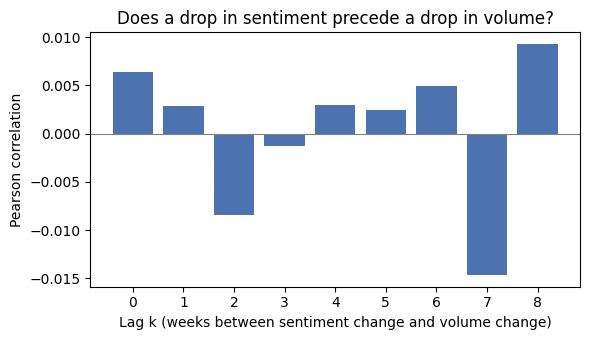

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(lag_pd["lag"], lag_pd["corr"], color="#4C72B0")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Lag k (weeks between sentiment change and volume change)")
ax.set_ylabel("Pearson correlation")
ax.set_title("Does a drop in sentiment precede a drop in volume?")
ax.set_xticks(lag_pd["lag"])
plt.tight_layout()
plt.show()


## 11. Clean up — unpersist + stop session

In [13]:
reviews_with_seller.unpersist()
print("reviews_with_seller unpersisted.")
print("Notebook 2 outputs:")
for p in sorted((ROOT / "outputs").glob("nb2_*.parquet")):
    print("  ", p.name)
spark.stop()


reviews_with_seller unpersisted.
Notebook 2 outputs:
   nb2_seller_sentiment_scores.parquet
